In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier # For classification
    # from sklearn.ensemble import RandomForestRegressor # For regression
from sklearn.metrics import accuracy_score, mean_squared_error # For evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt


In [3]:
    # Example: Loading a CSV file
    df = pd.read_excel("C:\\Users\\isell\\Downloads\\College_Success_Data.xlsx")

    # Assuming 'target_column' is your target variable
    X = df.drop("Target", axis=1)
    y = df["Target"]

    # Handle categorical features (example with one-hot encoding)
    X = pd.get_dummies(X, drop_first=True) # Avoids multicollinearity

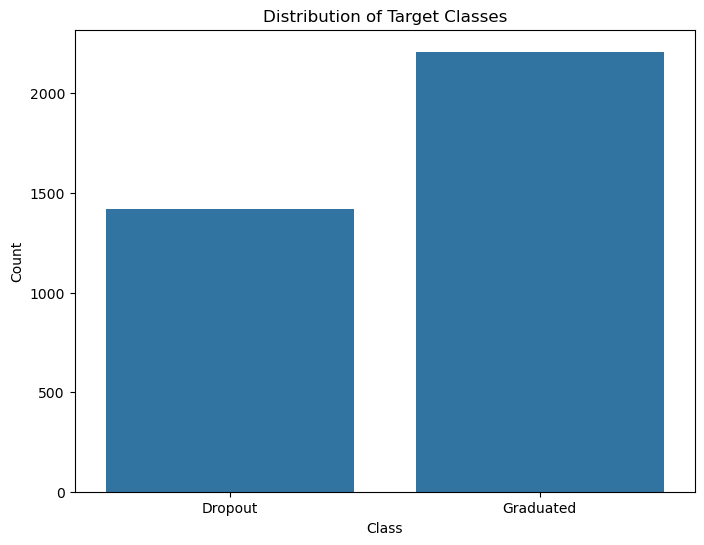

In [28]:


plt.figure(figsize=(8, 6))
sns.countplot(x='Target', data=df)
plt.title('Distribution of Target Classes')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [4]:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

In [5]:
# You can adjust n_estimators and other parameters as needed
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=123)
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=123)

In [6]:
y_pred = rf_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy}")

Model Accuracy: 0.9077134986225895


In [ ]:
#Testing Models with different hyperparameter



from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Create a Random Forest classifier
rf = RandomForestClassifier(random_state=42)

# Create GridSearchCV object
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the grid search to your data
grid_search.fit(X_train, y_train)


# Get the best parameters and best score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best accuracy: {grid_search.best_score_}")

# Use the best estimator
best_rf_model = grid_search.best_estimator_

Best parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best accuracy: 0.9097869309751321


In [25]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


grid_split = grid_search.fit(X_train, y_train)

print(classification_report(grid_split.predict(X_test), y_test))

              precision    recall  f1-score   support

     Dropout       0.90      0.84      0.87       263
   Graduated       0.91      0.95      0.93       463

    accuracy                           0.91       726
   macro avg       0.91      0.89      0.90       726
weighted avg       0.91      0.91      0.91       726

              precision    recall  f1-score   support

     Dropout       0.84      0.91      0.87       243
   Graduated       0.95      0.91      0.93       483

    accuracy                           0.91       726
   macro avg       0.89      0.91      0.90       726
weighted avg       0.91      0.91      0.91       726



In [2]:
pip install sklearn pandas matplotlib seaborn openpyxl

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [1]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Choose which class is considered "positive"
POS_CLASS = "Graduated"

# ---- DEFAULT MODEL ----
y_prob_default = rf_classifier.predict_proba(X_test)[:, 
                    list(rf_classifier.classes_).index(POS_CLASS)
                  ]

fpr_def, tpr_def, _ = roc_curve(y_test, y_prob_default, pos_label=POS_CLASS)
auc_def = auc(fpr_def, tpr_def)

# ---- OPTIMIZED MODEL ----
y_prob_best = best_rf_model.predict_proba(X_test)[:, 
                    list(best_rf_model.classes_).index(POS_CLASS)
                 ]

fpr_best, tpr_best, _ = roc_curve(y_test, y_prob_best, pos_label=POS_CLASS)
auc_best = auc(fpr_best, tpr_best)

# ---- PLOT ----
plt.figure(figsize=(8, 6))
plt.plot(fpr_def, tpr_def, label=f"Default RF (AUC = {auc_def:.3f})")
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Default vs Optimized Random Forest")
plt.legend()
plt.grid(True)
plt.show()

print("Default RF AUC:", auc_best)




ModuleNotFoundError: No module named 'sklearn'

In [14]:
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf_model.feature_importances_
})


In [19]:
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)
print(feature_importance_df.head(35))


                                           feature  importance
28             Curricular units 2nd sem (approved)    0.228385
22             Curricular units 1st sem (approved)    0.135268
29                Curricular units 2nd sem (grade)    0.133484
23                Curricular units 1st sem (grade)    0.079030
14                         Tuition fees up to date    0.064013
27          Curricular units 2nd sem (evaluations)    0.042826
17                               Age at enrollment    0.037754
21          Curricular units 1st sem (evaluations)    0.032145
3                                           Course    0.029448
16                              Scholarship holder    0.024460
26             Curricular units 2nd sem (enrolled)    0.020974
20             Curricular units 1st sem (enrolled)    0.020771
1                                 Application mode    0.019131
13                                          Debtor    0.018509
10                             Father's occupation    0

C:\Users\isell\AppData\Local\Temp\ipykernel_23612\2379645369.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df.head(5), palette='viridis')


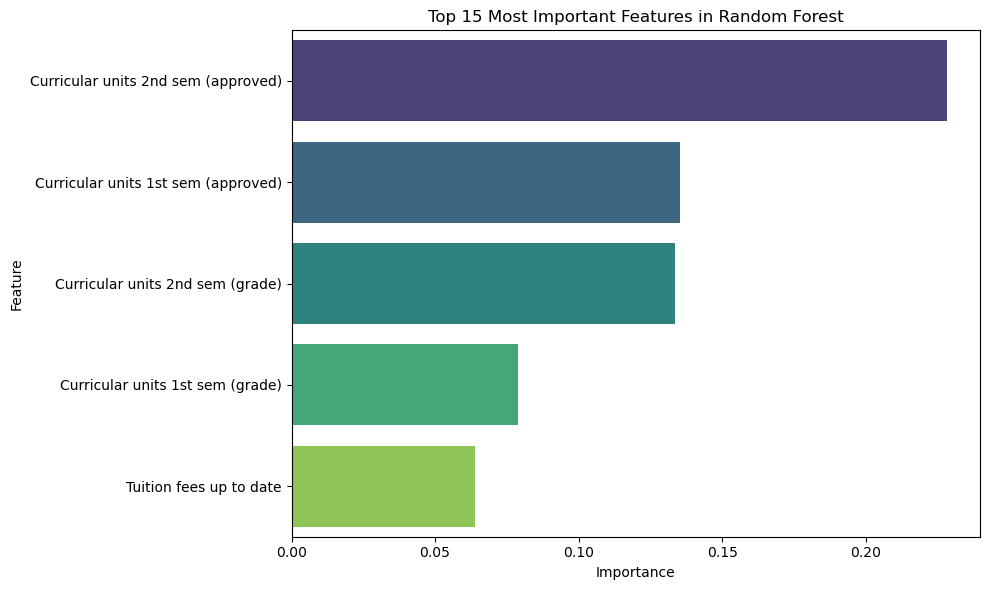

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(5), palette='viridis')
plt.title('Top 15 Most Important Features in Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [31]:
y_train_bin = (y_train == "Graduated").astype(int)
y_test_bin  = (y_test == "Graduated").astype(int)



NameError: name 'y_prob_best' is not defined